In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# File path
file_path ="C:\\Users\\User\\OneDrive\\Healthcare.csv"
# loading the csv
df = pd.read_csv(file_path)

# Viewing the first eleven rows
df.head(11)

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder
2,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza
3,4,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke
4,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease
5,6,49,Male,"vomiting, swelling, dizziness, fatigue",4,Heart Disease
6,7,69,Male,"anxiety, shortness of breath, appetite loss, c...",5,Food Poisoning
7,8,25,Other,"sore throat, weight loss, chest pain, depressi...",6,Bronchitis
8,9,11,Male,"insomnia, diarrhea, swelling",3,COVID-19
9,10,47,Male,"joint pain, shortness of breath, runny nose",3,Dermatitis


In [3]:
len(df)

25000

In [4]:
#checking Data Types
print(df.dtypes)

Patient_ID        int64
Age               int64
Gender           object
Symptoms         object
Symptom_Count     int64
Disease          object
dtype: object


In [5]:
#checking Rows and Column
rows, columns = df.shape
print("Rows:", rows)
print("Columns:", columns)

Rows: 25000
Columns: 6


In [6]:
#Checking Info of dataset if missing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Patient_ID     25000 non-null  int64 
 1   Age            25000 non-null  int64 
 2   Gender         25000 non-null  object
 3   Symptoms       25000 non-null  object
 4   Symptom_Count  25000 non-null  int64 
 5   Disease        25000 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.1+ MB


In [7]:
##Data Cleansing
#checking Duplicate
print(df.duplicated().sum())

0


In [8]:
#Checking Line Spacing
print(df.isnull().sum())

Patient_ID       0
Age              0
Gender           0
Symptoms         0
Symptom_Count    0
Disease          0
dtype: int64


In [9]:
# 1. Define which diseases are Chronic
chronic_list = [
    'Anxiety', 'Arthritis', 'Depression', 'Diabetes', 'Thyroid Disorder', 
    'Hypertension', 'Epilepsy', 'Liver Disease', 'IBS', "Parkinson's", 
    'Dementia', 'Obesity', 'Anemia', 'Chronic Kidney Disease', 
    'Heart Disease', 'Asthma', 'Tuberculosis'
]

# 2. Create the 'Illness_Type' column
# This says: If the disease is in the list, label it 'Chronic'. Otherwise, 'Acute/Episodic'.
df['Illness_Type'] = df['Disease'].apply(lambda x: 'Chronic' if x in chronic_list else 'Acute/Episodic')

# 3. Save the new version of your file
df.to_csv('Healthcare_Categorized.csv', index=False)

# 4 View the result
print(df[['Disease', 'Illness_Type']].head())

            Disease    Illness_Type
0           Allergy  Acute/Episodic
1  Thyroid Disorder         Chronic
2         Influenza  Acute/Episodic
3            Stroke  Acute/Episodic
4     Heart Disease         Chronic


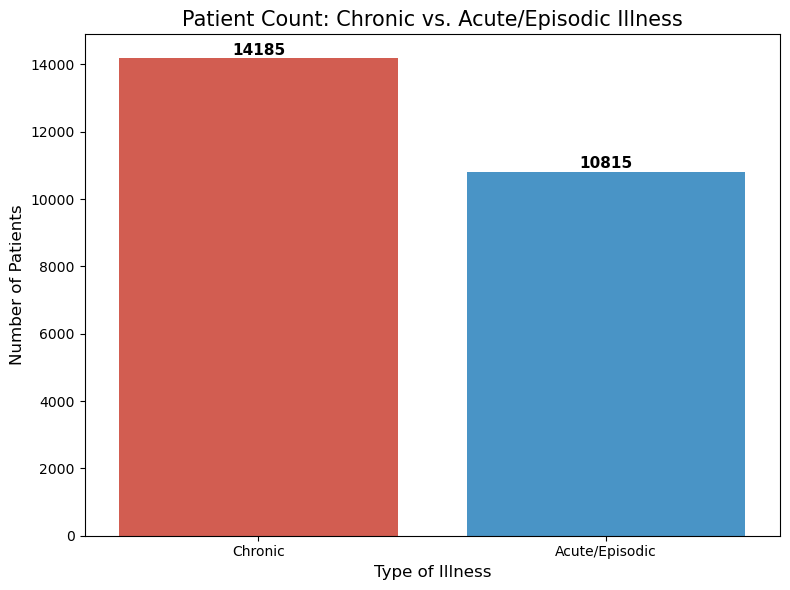

In [10]:
# 1. Create the categorization column
df['Illness_Type'] = df['Disease'].apply(lambda x: 'Chronic' if x in chronic_list else 'Acute/Episodic')

# 2. Count the number of patients in each category
# 3. We sort them so the bars appear in a specific order
type_counts = df['Illness_Type'].value_counts().reset_index()
type_counts.columns = ['Illness_Type', 'Count']

# 4. Create the Bar Chart
plt.figure(figsize=(8, 6))
sns.barplot(data=type_counts, 
            x='Illness_Type', 
            y='Count', 
            palette={'Chronic': '#e74c3c', 'Acute/Episodic': '#3498db'})

# 5. Add labels and title
plt.title('Patient Count: Chronic vs. Acute/Episodic Illness', fontsize=15)
plt.xlabel('Type of Illness', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# 6. Adding the exact count on top of each bar for clarity
for i, count in enumerate(type_counts['Count']):
    plt.text(i, count + 100, str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chronic_vs_acute_bar.png')
plt.show()

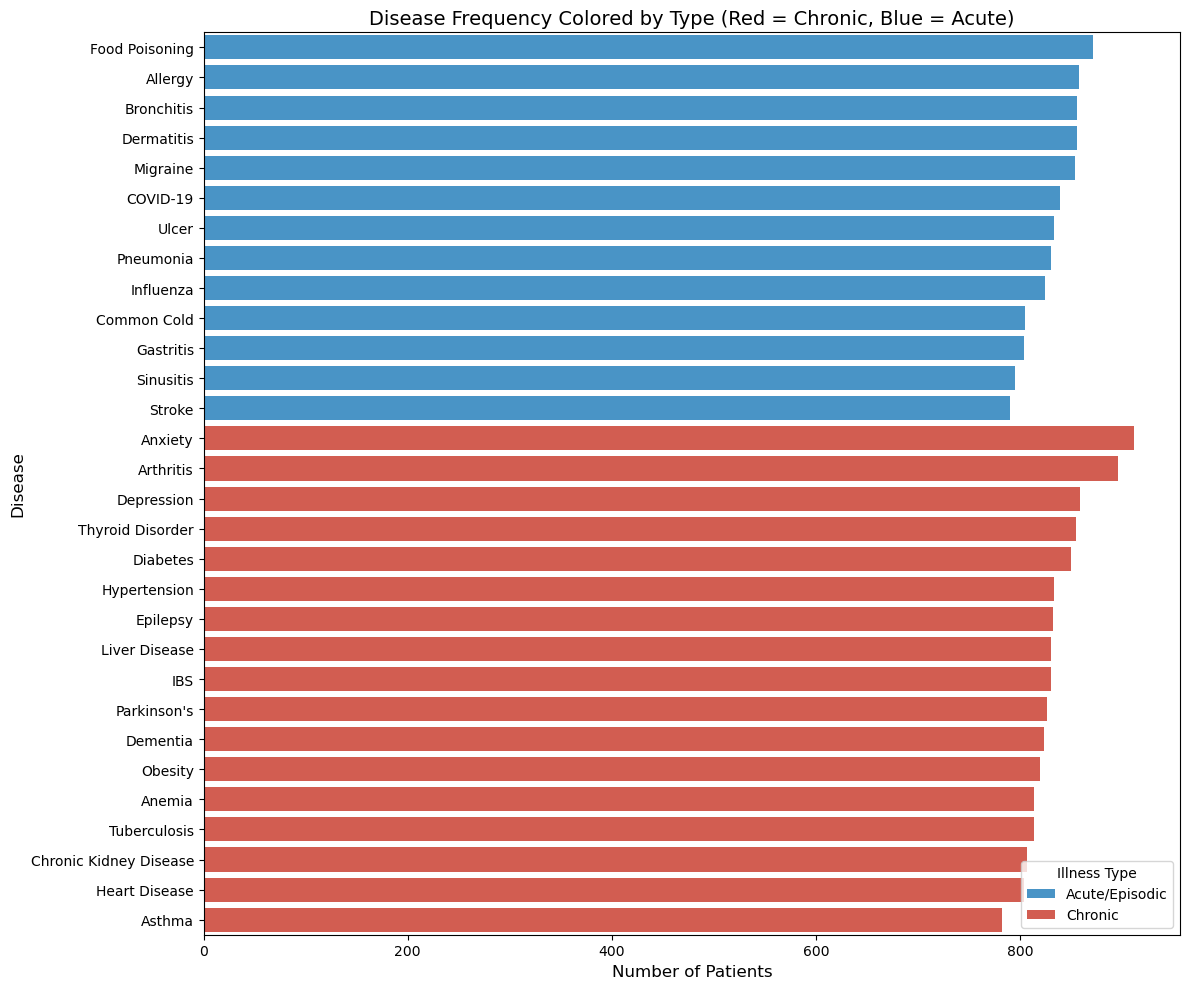

In [11]:
# 1. Create the Bar Chart for specific diseases
plt.figure(figsize=(12, 10))

# 2.Preparing data for sorting
disease_counts = df['Disease'].value_counts().reset_index()
disease_counts.columns = ['Disease', 'Count']
disease_counts['Category'] = disease_counts['Disease'].apply(lambda x: 'Chronic' if x in chronic_list else 'Acute/Episodic')
disease_counts = disease_counts.sort_values(by=['Category', 'Count'], ascending=[True, False])

# 2 .Plotting with specific colors
sns.barplot(data=disease_counts, 
            y='Disease', 
            x='Count', 
            hue='Category', 
            palette={'Chronic': '#e74c3c', 'Acute/Episodic': '#3498db'}, 
            dodge=False)

plt.title('Disease Frequency Colored by Type (Red = Chronic, Blue = Acute)', fontsize=14)
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('Disease', fontsize=12)
plt.legend(title='Illness Type')
plt.tight_layout()
plt.show()

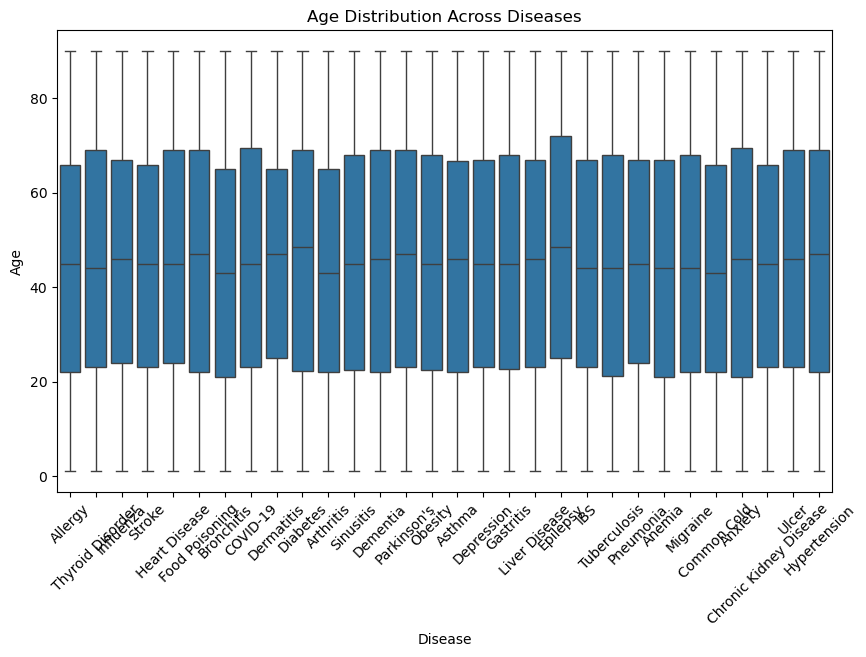

In [12]:
# Box plot
plt.figure(figsize=(10,6))
sns.boxplot(x='Disease', y='Age', data=df)

plt.title('Age Distribution Across Diseases')
plt.xticks(rotation=45)
plt.xlabel('Disease')
plt.ylabel('Age')

plt.show()

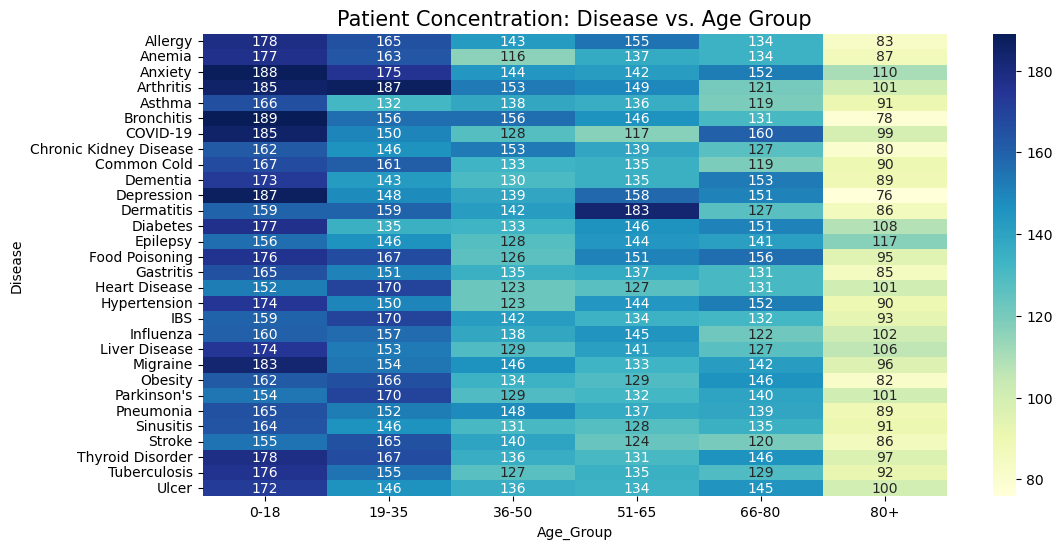

In [13]:

# --- 1. Heatmap: Patient Concentration ---
# Create age bins for a cleaner view
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 18, 35, 50, 65, 80, 100], 
                         labels=['0-18', '19-35', '36-50', '51-65', '66-80', '80+'])

# Pivot the data to get counts
heatmap_data = df.pivot_table(index='Disease', columns='Age_Group', values='Patient_ID', aggfunc='count').fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Patient Concentration: Disease vs. Age Group', fontsize=15)
plt.savefig('analysis_heatmap.png')


plt.show()

In [14]:
df.head()

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease,Illness_Type,Age_Group
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy,Acute/Episodic,19-35
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder,Chronic,66-80
2,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza,Acute/Episodic,66-80
3,4,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke,Acute/Episodic,51-65
4,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease,Chronic,51-65


In [15]:
df.tail()

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease,Illness_Type,Age_Group
24995,24996,42,Male,"runny nose, muscle pain, anxiety, depression, ...",6,Ulcer,Acute/Episodic,36-50
24996,24997,36,Male,"fever, blurred vision, insomnia, diarrhea, dep...",6,Common Cold,Acute/Episodic,36-50
24997,24998,70,Other,"anxiety, nausea, tremors",3,Anxiety,Chronic,66-80
24998,24999,9,Other,"muscle pain, rash, diarrhea, joint pain",4,Obesity,Chronic,0-18
24999,25000,27,Female,"sweating, abdominal pain, fever, insomnia, blu...",7,Parkinson's,Chronic,19-35


Chart saved as gender_disease_relationship.png
   Disease  Gender  Count
0  Allergy  Female    297
1  Allergy    Male    265
2   Anemia  Female    253
3   Anemia    Male    286
4  Anxiety  Female    305


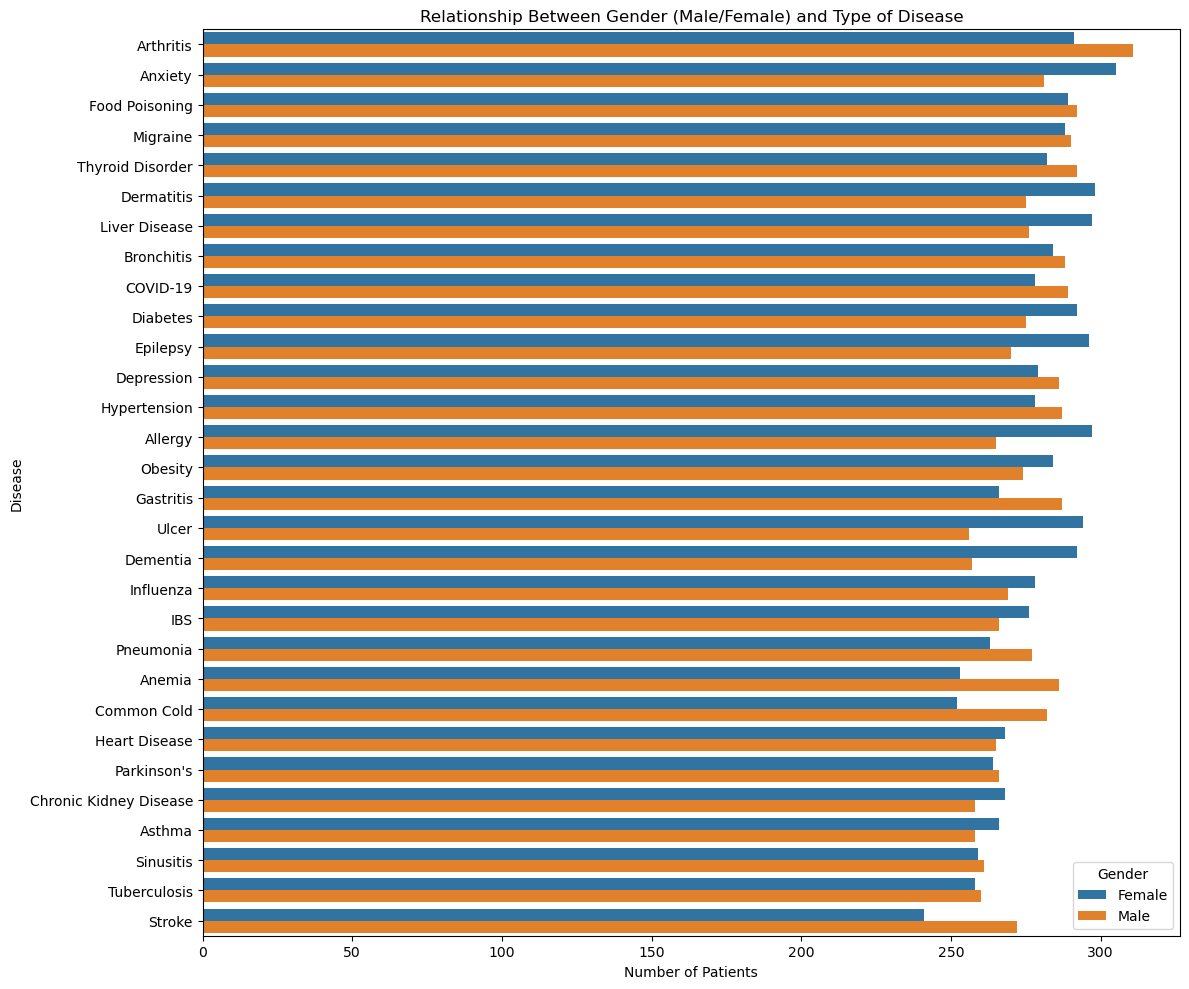

In [18]:
# Filter for Male and Female if desired, or keep all. 
# The user asked for "male female relationship", so I'll focus on those but it's safer to see what's there.
# Let's filter for just Male and Female for the specific request.
df_filtered = df[df['Gender'].isin(['Male', 'Female'])]

# Count diseases per gender
gender_disease_counts = df_filtered.groupby(['Disease', 'Gender']).size().reset_index(name='Count')

# Sort diseases by total count for better visualization
total_counts = df_filtered['Disease'].value_counts()
sorted_diseases = total_counts.index.tolist()

# Plotting
plt.figure(figsize=(12, 10))
sns.barplot(data=gender_disease_counts, y='Disease', x='Count', hue='Gender', order=sorted_diseases)
plt.title('Relationship Between Gender (Male/Female) and Type of Disease')
plt.xlabel('Number of Patients')
plt.ylabel('Disease')
plt.tight_layout()
plt.savefig('gender_disease_relationship.png')

print("Chart saved as gender_disease_relationship.png")
print(gender_disease_counts.head())

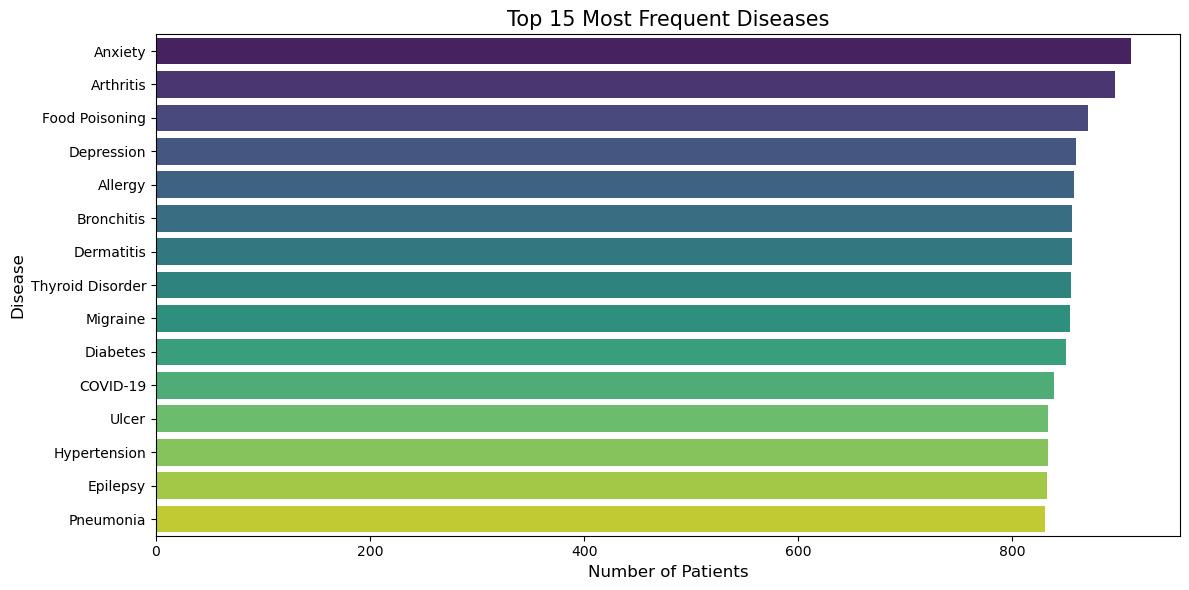

In [16]:


# Calculate the frequency of each disease and select the top 15
disease_counts = df['Disease'].value_counts().head(15)

# Set the figure size
plt.figure(figsize=(12, 6))

# Create a horizontal bar chart
sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='viridis')

# Add titles and labels
plt.title('Top 15 Most Frequent Diseases', fontsize=15)
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('Disease', fontsize=12)

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Display the plot
plt.show()

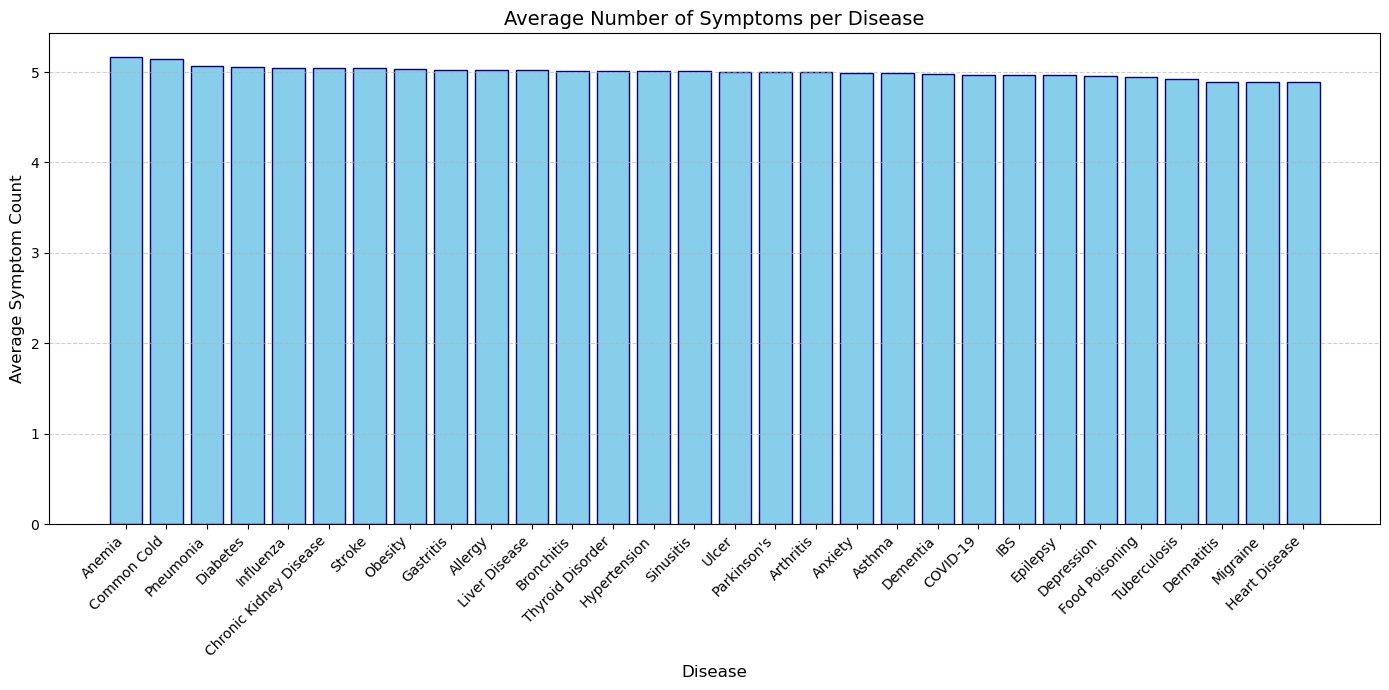

In [17]:


# 1. Group by 'Disease' and calculate the average 'Symptom_Count'
# We also reset the index to turn the result back into a flat DataFrame
avg_symptoms = df.groupby('Disease')['Symptom_Count'].mean().reset_index()

# 2. Sort the data by the average count for a better visual flow (highest to lowest)
avg_symptoms = avg_symptoms.sort_values(by='Symptom_Count', ascending=False)

# 3. Create the bar chart
plt.figure(figsize=(14, 7))
plt.bar(avg_symptoms['Disease'], avg_symptoms['Symptom_Count'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Disease', fontsize=12)
plt.ylabel('Average Symptom Count', fontsize=12)
plt.title('Average Number of Symptoms per Disease', fontsize=14)

# 5. Rotate disease names on the x-axis so they are readable
plt.xticks(rotation=45, ha='right')

# 6. Optional: Add a horizontal grid to make values easier to track
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 7. Adjust layout to ensure labels aren't cut off
plt.tight_layout()

# 8.. Display the chart
plt.show()